# Brandbook Preview

Set `JSON_PATH` to any brandbook JSON and run all cells.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import base64
from io import BytesIO
from pprint import pprint

from IPython.display import display, Markdown, Image, SVG, HTML
import matplotlib.pyplot as plt

JSON_PATH = Path('brandbook.slim.json')  # change me
print('CWD:', Path.cwd())
print('JSON_PATH:', JSON_PATH)


CWD: /Users/zan/Desktop/MSBA/spring/ capstone/code/brandbook_package
JSON_PATH: brandbook.slim.json


In [2]:
if not JSON_PATH.exists():
    print('JSON not found. Available JSON files:')
    for p in Path('.').rglob('*.json'):
        print(' -', p)
    raise FileNotFoundError(JSON_PATH)

data = json.loads(JSON_PATH.read_text())
display(Markdown(f'**Loaded:** `{JSON_PATH}`'))
print('Top-level keys:')
pprint(list(data.keys()))


**Loaded:** `brandbook.slim.json`

Top-level keys:
['source_url',
 'pages_crawled',
 'colors',
 'fonts',
 'css_vars',
 'sectioned_styles',
 'data_viz_palette',
 'images',
 'data_viz_notes']


In [3]:
display(Markdown('## Summary'))
summary = {
    'source_url': data.get('source_url'),
    'pages_crawled': data.get('pages_crawled'),
    'num_colors': len(data.get('colors', [])),
    'num_fonts': len(data.get('fonts', {}).get('families', [])),
    'num_images': len(data.get('images', {}).get('files', [])),
    'has_base64': bool(data.get('images', {}).get('base64'))
}
pprint(summary)


## Summary

{'has_base64': True,
 'num_colors': 20,
 'num_fonts': 5,
 'num_images': 7,
 'pages_crawled': 5,
 'source_url': 'https://wealthtender.com/'}


In [4]:
display(Markdown('## Colors'))
colors = data.get('colors', [])
pprint(colors[:20])


## Colors

['rgb(17, 24, 39)',
 'rgb(28, 65, 125)',
 'rgb(107, 114, 128)',
 'rgb(255, 255, 255)',
 'rgb(55, 65, 81)',
 'rgb(227, 245, 254)',
 'rgb(121, 0, 0)',
 'rgb(75, 85, 99)',
 'rgb(235, 235, 255)',
 'rgb(0, 0, 0)',
 'rgb(50, 55, 60)',
 'rgb(61, 61, 155)',
 'rgb(31, 68, 123)',
 'rgb(87, 87, 221)',
 'rgb(31, 31, 31)',
 'rgb(245, 245, 245)',
 'rgb(90, 143, 208)',
 'rgb(29, 161, 242)',
 '#000',
 'rgb(153, 153, 153)']


### Color Swatches

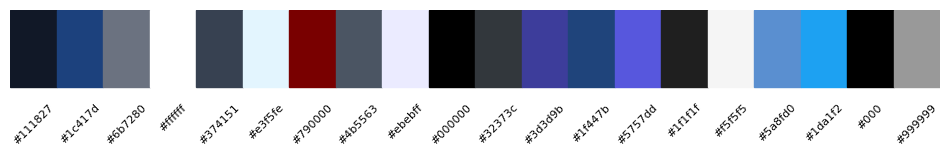

In [5]:
display(Markdown('### Color Swatches'))
import re
def normalize_color(c):
    if not isinstance(c, str):
        return None
    s = c.strip().lower()
    if s.startswith('#'):
        return s
    m = re.match(r'rgb\(([^)]+)\)', s)
    if m:
        parts = [p.strip() for p in m.group(1).split(',')]
        if len(parts) >= 3:
            try:
                r = int(float(parts[0])); g = int(float(parts[1])); b = int(float(parts[2]))
                return f'#{r:02x}{g:02x}{b:02x}'
            except Exception:
                return None
    return None

raw_swatches = colors[:20]
swatches = [normalize_color(c) for c in raw_swatches]
swatches = [c for c in swatches if c]
if swatches:
    fig, ax = plt.subplots(figsize=(max(6, len(swatches)*0.6), 1.6))
    for i, c in enumerate(swatches):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.text(i + 0.5, -0.2, c, ha='center', va='top', fontsize=8, rotation=45)
    ax.set_xlim(0, len(swatches))
    ax.set_ylim(-0.6, 1)
    ax.axis('off')
    plt.show()
else:
    print('No valid colors found.')


## Data Viz Palette

['#111827',
 '#1c417d',
 '#6b7280',
 '#ffffff',
 '#e3f5fe',
 '#790000',
 '#5757dd',
 '#5a8fd0',
 '#1da1f2',
 '#000000',
 '#3d3d9b',
 '#32373c']


### Data Viz Swatches

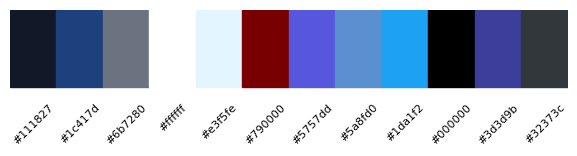

In [6]:
display(Markdown('## Data Viz Palette'))
dv = data.get('data_viz_palette', [])
pprint(dv)

display(Markdown('### Data Viz Swatches'))
if dv:
    fig, ax = plt.subplots(figsize=(max(6, len(dv)*0.6), 1.6))
    for i, c in enumerate(dv):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.text(i + 0.5, -0.2, c, ha='center', va='top', fontsize=8, rotation=45)
    ax.set_xlim(0, len(dv))
    ax.set_ylim(-0.6, 1)
    ax.axis('off')
    plt.show()
else:
    print('No data viz palette found.')


In [7]:
display(Markdown('## Fonts'))
fonts = data.get('fonts', {})
pprint(fonts)


## Fonts

{'families': ['opensansregular, sans-serif',
              'opensanssemibold, sans-serif',
              '"Open Sans", sans-serif',
              'opensanslight, sans-serif',
              'Roboto, Arial, sans-serif'],
 'sizes': ['16px',
           '12px',
           '14px',
           '20px',
           '18px',
           '60px',
           '36px',
           '24px',
           '0px',
           '11px'],
 'weights': ['400', '600', '700']}


In [8]:
display(Markdown('### Font Preview'))
families = fonts.get('families', [])
sample = 'Wealthtender — The quick brown fox jumps over the lazy dog 1234567890'
if not families:
    print('No font families found.')
else:
    html = ['<div style="font-family: Arial, sans-serif;">']
    for fam in families:
        html.append(f'<div style="margin:8px 0; font-family:{fam}; font-size:20px;"><b>{fam}</b><br>{sample}</div>')
    html.append('</div>')
    display(HTML(''.join(html)))


### Font Preview

In [39]:
display(Markdown('## Sectioned Styles'))
sectioned = data.get('sectioned_styles', {})
if not sectioned:
    print('No sectioned styles found. Re-run crawler after enabling sectioned capture.')
else:
    by_section = sectioned.get('by_section', {})
    by_use = sectioned.get('by_use', {})
    if by_section:
        display(Markdown('### By Section'))
        for section, comps in by_section.items():
            display(Markdown(f'#### {section}'))
            for use, vals in comps.items():
                display(Markdown(f'**{use}**'))
                print('fonts:', vals.get('fontFamilies'))
                print('sizes:', vals.get('fontSizes'))
                print('weights:', vals.get('fontWeights'))
                print('colors:', vals.get('colors'))
                print('backgrounds:', vals.get('backgroundColors'))
                print('')
    if by_use:
        display(Markdown('### By Use (overall)'))
        for use, vals in by_use.items():
            display(Markdown(f'**{use}**'))
            print('fonts:', vals.get('fontFamilies'))
            print('sizes:', vals.get('fontSizes'))
            print('weights:', vals.get('fontWeights'))
            print('colors:', vals.get('colors'))
            print('backgrounds:', vals.get('backgroundColors'))
            print('')


## Sectioned Styles

### By Section

#### main

**headings**

fonts: ['opensanssemibold, sans-serif', 'opensansregular, sans-serif']
sizes: ['36px', '18px', '60px', '24px', '16px']
weights: ['400', '700']
colors: ['rgb(17, 24, 39)', 'rgb(28, 65, 125)', 'rgb(90, 143, 208)', 'rgb(50, 55, 60)']
backgrounds: []



...

fonts: ['opensansregular, sans-serif', 'Roboto, Arial, sans-serif']
sizes: ['16px', '11px', '10px']
weights: ['400']
colors: ['rgb(28, 65, 125)', 'rgb(17, 24, 39)', 'rgb(0, 0, 0)']
backgrounds: ['rgb(28, 65, 125)', 'rgb(255, 255, 255)']



**forms**

fonts: ['opensansregular, sans-serif', 'opensanssemibold, sans-serif', '"Open Sans", sans-serif']
sizes: ['16px', '12px', '14px']
weights: ['400', '600']
colors: ['rgb(17, 24, 39)', 'rgb(255, 255, 255)']
backgrounds: ['rgb(255, 255, 255)', 'rgb(31, 68, 123)']



**containers**

fonts: ['opensansregular, sans-serif']
sizes: ['16px']
weights: ['400']
colors: ['rgb(17, 24, 39)']
backgrounds: ['rgb(227, 245, 254)']



In [40]:
display(Markdown('## Images'))
images = data.get('images', {})
pprint(images.get('files', []))


## Images

['brandbook_output/assets/logo-blue.svg',
 'brandbook_output/assets/logo-mark.svg',
 'brandbook_output/assets/logo-wordmark.svg',
 'brandbook_output/assets/article-divider.png']


### Image Preview (from base64 if present)

**logo-blue.svg**

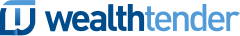

**logo-mark.svg**

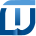

**logo-wordmark.svg**

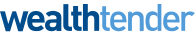

**article-divider.png**

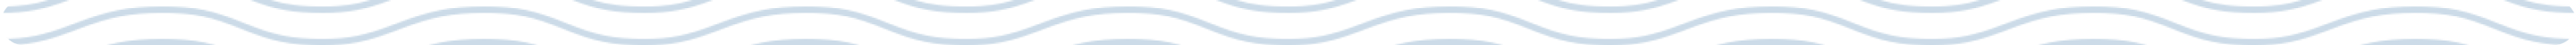

In [41]:
display(Markdown('### Image Preview (from base64 if present)'))
base64_map = images.get('base64', {})
files = images.get('files', [])
if not files:
    print('No image files listed.')

for f in files:
    p = Path(f)
    display(Markdown(f'**{p.name}**'))
    if f in base64_map:
        raw = base64.b64decode(base64_map[f])
        if p.suffix.lower() == '.svg':
            try:
                display(SVG(raw.decode('utf-8')))
            except Exception as e:
                print('SVG preview failed:', e)
        else:
            display(Image(data=raw))
    else:
        if p.exists():
            if p.suffix.lower() == '.svg':
                display(SVG(filename=str(p)))
            else:
                display(Image(filename=str(p)))
        else:
            print('File not found:', p)
